# Итоговая домашняя работа по предмету "Семинар наставника": Trino + PostgreSQL + MySQL + Iceberg + Визуализация

**Студент:** Паламарчук Екатерина

In [1]:
import sys
print("Текущий Python:", sys.executable)
print("Версия:", sys.version)

Текущий Python: /Users/katrinnaya/hse/mentorsem_final_hw/.venv/bin/python
Версия: 3.13.3 (main, Apr  8 2025, 13:54:08) [Clang 16.0.0 (clang-1600.0.26.6)]


In [32]:
# Импорт необходимых библиотек
# Для подключения к СУБД
import psycopg2
import mysql.connector

# Для Trino и аналитики
import trino
import pandas as pd
import matplotlib.pyplot as plt
import random
from datetime import datetime, timedelta

## Создание таблиц и данных в PostgreSQL

In [33]:
# === PostgreSQL: пересоздаём всегда ===
pg_conn = psycopg2.connect(
    host="localhost",
    port=55432,
    dbname="demo_db",
    user="admin",
    password="admin"
)
pg_cur = pg_conn.cursor()

# Удаляем старые таблицы
pg_cur.execute("DROP TABLE IF EXISTS trn_orders")
pg_cur.execute("DROP TABLE IF EXISTS trn_customers")

# Создаём заново
pg_cur.execute("CREATE TABLE trn_customers (customer_id SERIAL PRIMARY KEY, name VARCHAR(100))")
pg_cur.execute("""
    CREATE TABLE trn_orders (
        order_id BIGINT PRIMARY KEY,
        customer_id INT,
        order_ts TIMESTAMP,
        total_amount NUMERIC(10,2)
    )
""")

# Генерация клиентов
customers = [(f"Customer {i}",) for i in range(1, 11)]
pg_cur.executemany("INSERT INTO trn_customers (name) VALUES (%s)", customers)

# Генерация заказов
pg_cur.execute("SELECT customer_id FROM trn_customers")
customer_ids = [row[0] for row in pg_cur.fetchall()]

orders = []
for i in range(1, 9001):
    customer_id = customer_ids[(i - 1) % len(customer_ids)]
    days_ago = random.randint(0, 730)
    minutes_ago = random.randint(0, 1440)
    order_ts = datetime.now() - timedelta(days=days_ago, minutes=minutes_ago)
    total_amount = round(10 + random.random() * 990, 2)
    orders.append((i, customer_id, order_ts, total_amount))

pg_cur.executemany(
    "INSERT INTO trn_orders (order_id, customer_id, order_ts, total_amount) VALUES (%s, %s, %s, %s)",
    orders
)

pg_conn.commit()
pg_cur.close()
pg_conn.close()
print(f"PostgreSQL: создано {len(customers)} клиентов и {len(orders)} заказов")

PostgreSQL: создано 10 клиентов и 9000 заказов


## Создание таблиц и данных в MySQL

In [34]:
# === MySQL: пересоздаём всегда ===
mysql_conn = mysql.connector.connect(
    host="localhost",
    port=5506,
    user="admin",
    password="admin",
    database="demo_db"
)
mysql_cur = mysql_conn.cursor()

# Удаляем и пересоздаём
mysql_cur.execute("DROP TABLE IF EXISTS trn_payments")
mysql_cur.execute("""
    CREATE TABLE trn_payments (
        payment_id BIGINT PRIMARY KEY,
        order_id BIGINT,
        amount DECIMAL(10,2),
        paid_at DATETIME  -- ← ИСПРАВЛЕНО: DATETIME вместо TIMESTAMP
    )
""")

# Получаем заказы из PostgreSQL
pg_conn2 = psycopg2.connect(
    host="localhost", port=55432, dbname="demo_db",
    user="admin", password="admin"
)
pg_cur2 = pg_conn2.cursor()
pg_cur2.execute("SELECT order_id, total_amount, order_ts FROM trn_orders ORDER BY order_id")
orders = pg_cur2.fetchall()
pg_cur2.close()
pg_conn2.close()

print(f"📥 Загружено {len(orders)} заказов из PostgreSQL")

# Генерация платежей
payments = []
payment_id = 1
for i, (order_id, total_amount, order_ts) in enumerate(orders):
    rn = i + 1
    if rn % 10 in (0, 1, 2):  # 30% не оплачено
        continue

    if rn % 4 == 0:  # Два платежа
        total_amount_float = float(total_amount)
        amount1 = round(total_amount_float * (0.4 + random.random() * 0.4), 2)
        amount2 = round(total_amount_float - amount1, 2)
        paid_at1 = order_ts + timedelta(days=1 + int(random.random() * 3))
        paid_at2 = order_ts + timedelta(days=4 + int(random.random() * 5))
        payments.append((payment_id, order_id, amount1, paid_at1))
        payment_id += 1
        payments.append((payment_id, order_id, amount2, paid_at2))
        payment_id += 1
    else:  # Один платеж
        total_amount_float = float(total_amount)
        amount = round(total_amount_float * (0.95 + random.random() * 0.15), 2)
        paid_at = order_ts + timedelta(days=1 + int(random.random() * 7))
        payments.append((payment_id, order_id, amount, paid_at))
        payment_id += 1

print(f"📤 Сгенерировано {len(payments)} платежей")

# Вставка
if payments:
    mysql_cur.executemany(
        "INSERT INTO trn_payments (payment_id, order_id, amount, paid_at) VALUES (%s, %s, %s, %s)",
        payments
    )
    mysql_conn.commit()
else:
    print("⚠️ Нет платежей для вставки!")

mysql_cur.close()
mysql_conn.close()
print("Данные в MySQL готовы")

📥 Загружено 9000 заказов из PostgreSQL
📤 Сгенерировано 7650 платежей
Данные в MySQL готовы


In [35]:
# Подключение к Trino
conn = trino.dbapi.connect(host="localhost", port=8080, user="student")
cur = conn.cursor()

def q(sql):
    cur.execute(sql)
    rows = cur.fetchall()
    return pd.DataFrame(rows, columns=[c[0] for c in cur.description]) if cur.description else None

print("Подключено к Trino для аналитики")

Подключено к Trino для аналитики


In [36]:
# Проверка доступности каталогов
print("=== PostgreSQL ===")
display(q("SHOW TABLES FROM postgresql.public"))

print("\n=== MySQL ===")
display(q("SHOW TABLES FROM mysql.demo_db"))

=== PostgreSQL ===


,Table
0,trn_customers
1,trn_orders



=== MySQL ===


,Table
0,trn_payments


## Агрегации

In [37]:
# Заказы по дням (PostgreSQL)
df_orders_daily = q("""
SELECT
    DATE_TRUNC('DAY', order_ts) AS dt,
    COUNT(*) AS orders_cnt,
    SUM(total_amount) AS revenue
FROM postgresql.public.trn_orders
GROUP BY 1
ORDER BY 1
""")

# Платежи по дням (MySQL)
df_payments_daily = q("""
SELECT 
    DATE_TRUNC('DAY', paid_at) AS dt,
    COUNT(*) AS payments_cnt,
    SUM(amount) AS paid_amount
FROM mysql.demo_db.trn_payments
GROUP BY 1
ORDER BY 1
""")


In [38]:
# Создаём финальный DataFrame для визуализации и сохранения
df_final = df_orders_daily.merge(df_payments_daily, on="dt", how="left")
df_final = df_final.fillna({"payments_cnt": 0, "paid_amount": 0})
df_final['payment_coverage'] = df_final['paid_amount'] / df_final['revenue']
df_final.head()

,dt,orders_cnt,revenue,payments_cnt,paid_amount,payment_coverage
0,2024-01-06,1,801.73,0.0,0,0E+2
1,2024-01-07,19,8900.45,0.0,0,0E+2
2,2024-01-08,14,10088.55,1.0,304.84,0.03021643348152113039039306937
3,2024-01-09,5,2316.67,3.0,896.79,0.3871030401395105906322436946
4,2024-01-10,11,5722.70,8.0,4021.01,0.7026421094937704230520558478


## Визуализация 1: Выручка по дням

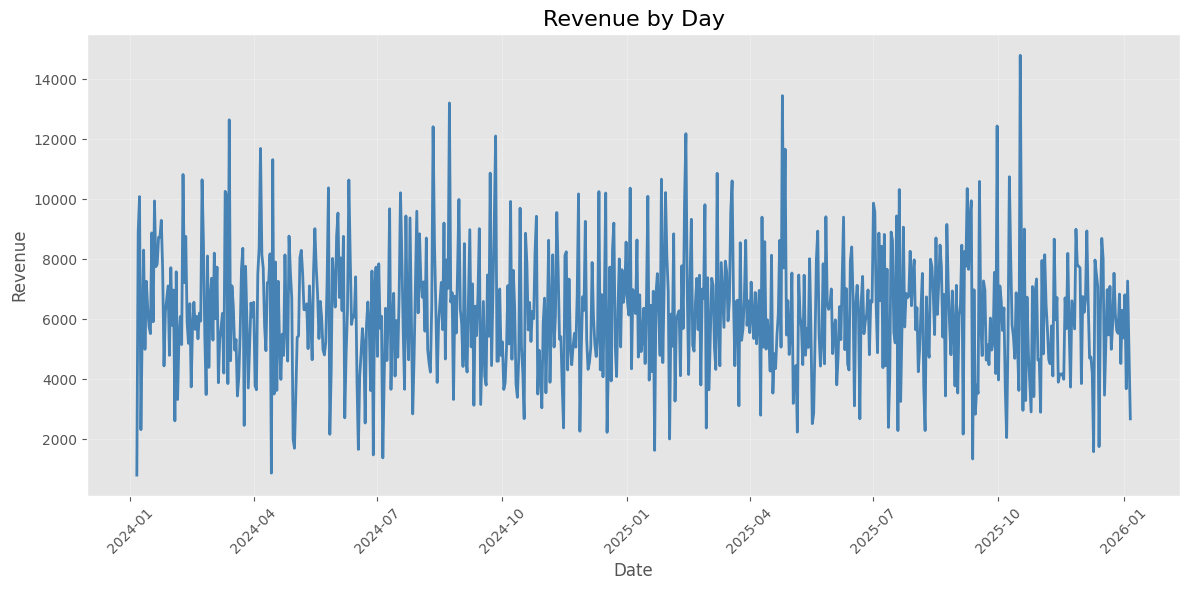

In [39]:
plt.figure(figsize=(12, 6))
plt.plot(df_final["dt"], df_final["revenue"], color='steelblue', linewidth=2)
plt.title("Revenue by Day", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Визуализация 2: Покрытие платежей

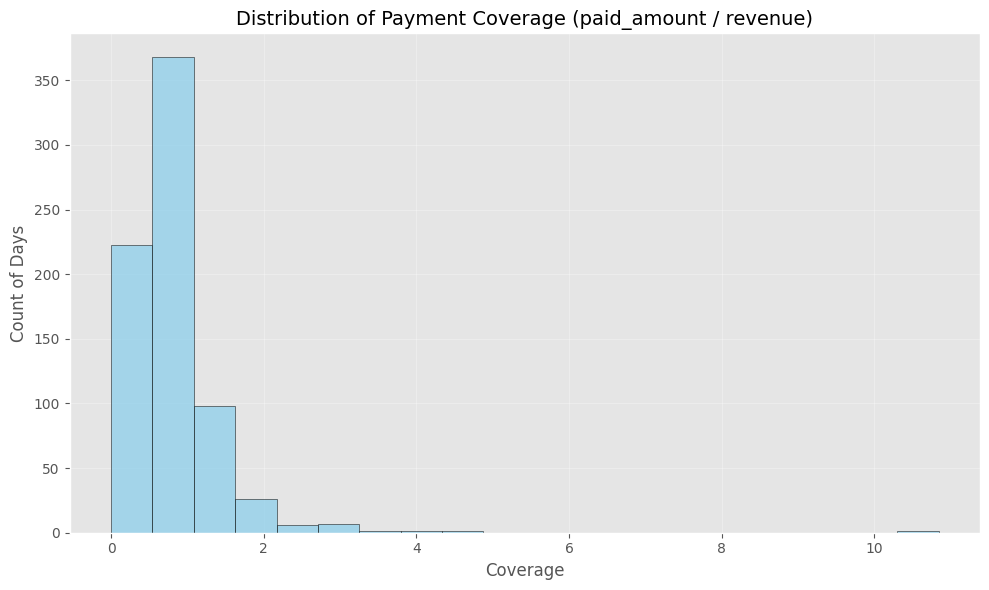

In [40]:
plt.figure(figsize=(10, 6))
plt.hist(df_final["payment_coverage"].dropna(), bins=20, color='skyblue', edgecolor='black', alpha=0.7)
plt.title("Distribution of Payment Coverage (paid_amount / revenue)", fontsize=14)
plt.xlabel("Coverage")
plt.ylabel("Count of Days")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Сохранение в Iceberg

In [41]:
pg_conn = psycopg2.connect(
    host="localhost",
    port=55432,
    dbname="demo_db",
    user="admin",
    password="admin"
)
pg_cur = pg_conn.cursor()

# Таблица для таблиц
pg_cur.execute("""
    CREATE TABLE IF NOT EXISTS iceberg_tables (
        catalog_name VARCHAR(255) NOT NULL,
        table_namespace VARCHAR(255) NOT NULL,
        table_name VARCHAR(255) NOT NULL,
        metadata_location VARCHAR(4096),
        previous_metadata_location VARCHAR(4096),
        PRIMARY KEY (catalog_name, table_namespace, table_name)
    )
""")

# Таблица для схем (namespace)
pg_cur.execute("""
    CREATE TABLE IF NOT EXISTS iceberg_namespace_properties (
        catalog_name VARCHAR(255) NOT NULL,
        namespace VARCHAR(255) NOT NULL,
        property_key VARCHAR(255) NOT NULL,
        property_value VARCHAR(10000),
        PRIMARY KEY (catalog_name, namespace, property_key)
    )
""")

pg_conn.commit()
pg_cur.close()
pg_conn.close()

print("Созданы обе служебные таблицы Iceberg в PostgreSQL")

Созданы обе служебные таблицы Iceberg в PostgreSQL


In [42]:
# Создаём схему и таблицу
q("CREATE SCHEMA IF NOT EXISTS iceberg.homework")

q("""
CREATE TABLE IF NOT EXISTS iceberg.homework.final_metrics (
    dt TIMESTAMP,
    orders_cnt BIGINT,
    revenue DOUBLE,
    payments_cnt BIGINT,
    paid_amount DOUBLE,
    payment_coverage DOUBLE
)
""")

# Вставляем данные
for _, row in df_final.iterrows():
    paid_amount = row['paid_amount'] if pd.notna(row['paid_amount']) else 0
    coverage = row['payment_coverage'] if pd.notna(row['payment_coverage']) else 'NULL'
    q(f"""
    INSERT INTO iceberg.homework.final_metrics VALUES (
        TIMESTAMP '{row['dt']}',
        {row['orders_cnt']},
        {row['revenue']},
        {row['payments_cnt']},
        {paid_amount},
        {coverage}
    )
    """)

print("Данные сохранены в Iceberg:")
display(q("SELECT * FROM iceberg.homework.final_metrics LIMIT 5"))

Данные сохранены в Iceberg:


,dt,orders_cnt,revenue,payments_cnt,paid_amount,payment_coverage
0,2025-12-13,12,7095.99,12,5935.18,0.836413
1,2026-01-01,8,5374.28,6,2900.61,0.539721
2,2025-12-28,13,5528.90,8,4784.18,0.865304
3,2026-01-03,6,3680.87,9,3962.82,1.076599
4,2025-12-24,14,5827.92,5,2061.76,0.353773


In [43]:
# Закрытие соединения
cur.close()
conn.close()
print("Работа завершена. Соединение закрыто")

Работа завершена. Соединение закрыто


## Итоги

Все требования задания выполнены:
- ✅ Подключение к Trino и проверка каталогов **PostgreSQL** и **MySQL**
- ✅ Два агрегирующих SQL-запроса по **реальным таблицам** с числовыми/датовыми полями
- ✅ Результаты загружены в `pandas.DataFrame`
- ✅ Построено **два графика** с подписями осей и заголовками
- ✅ Создана схема и **Iceberg-таблица**, данные сохранены 